# OP3 positive controls: what do replicate wells of an identical treatment look like?

In every OP3 plate, columns 1 and 2 hold two positive-control compounds and column 3 holds DMSO,
each in all eight rows (A–H). The treatment is identical across these eight wells, so any difference
between them comes from the well and its position, not from the compound.

Three tests:

1. **DEGs between two wells of the same treatment** (plates as replicates, fixed layout), compared with
   DEGs of the compound against DMSO in the same row. This is the OP3 analogue of the Parse DEG floor.
2. **Share of the between-well difference due to the well** (as in Figure 2A), for an active compound
   versus DMSO: does well noise depend on the treatment?
3. **Split-half ceiling with a real response**: correlation of the response between two halves of one
   well versus two different wells of the same compound (as in Figure 5A).

What this can and cannot show: it measures what the design does when the treatment is known to be
identical. It cannot tell whether a Parse inert protein has a weak real effect.

In [1]:
import os, itertools, warnings
import numpy as np
import pandas as pd
import h5py
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt

OP3_FILE = "data/op3/sc_counts_reannotated_with_counts.h5ad"
CACHE_DIR = "cache/op3_posctrl"
FIG_DIR = "figures"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
F_PB = os.path.join(CACHE_DIR, "pb_ctrl_wells.npz")      # pseudobulks of control wells
F_META_FULL = os.path.join(CACHE_DIR, "pb_ctrl_meta_full.csv")
F_META_EQ = os.path.join(CACHE_DIR, "pb_ctrl_meta_eq.csv")
F_DEG = os.path.join(CACHE_DIR, "deg_ctrl_wells.csv")    # one row per DESeq2 run (resumable)
FIG_OUT = os.path.join(FIG_DIR, "FigOP3_positive_controls.png")

SEED = 0
CTRL_COLS = [1, 2]        # positive controls
DMSO_COL = 3
MIN_CELLS_WELL = 50       # min cells per well for the DEG pseudobulk (as in the paper)
MIN_CELLS_EQ = 40         # min cells per well for equalized halves (tests 2 and 3)
N_TOP_GENES = 2000        # genes most expressed in DMSO, per cell type (response-independent)
DEG_PADJ, DEG_LFC = 0.05, 0.25
MIN_PLATES_DEG = 4        # skip a DESeq2 run with fewer plates than this
DEG_MAX_PAIRS = None      # None = all 28 row pairs; set e.g. 6 for a quick first run
DEG_CELL_TYPES = None     # None = all CELL_TYPES
N_CPUS = 8
EDGE_ROWS = {"A", "H"}
PARSE_STRICT_INERT_DEG = 389   # Parse: median DEGs of receptor-negative proteins vs PBS

# merge T-cell subtypes as in the paper; edit if the labels differ
CELL_TYPE_MERGE = {"T cells CD4+": "T cells", "T cells CD8+": "T cells", "T regulatory cells": "T cells"}

## 1. Load metadata and check the layout

In [2]:
a = ad.read_h5ad(OP3_FILE, backed="r")
obs = a.obs[["plate_name", "well", "row", "col", "donor_id", "sm_name", "cell_type"]].copy()
obs = obs.reset_index(drop=True)            # position = row in raw/X
for c in ["plate_name", "well", "row", "donor_id", "sm_name", "cell_type"]:
    obs[c] = obs[c].astype(str)

# raw UMI counts are stored in raw/X (X itself is log-normalized); read the CSR arrays directly
H5 = h5py.File(OP3_FILE, "r")
RAW = H5["raw/X"]
INDPTR = RAW["indptr"][:]
N_OBS, N_VARS = (int(v) for v in RAW.attrs["shape"])
assert N_OBS == len(obs), "raw/X rows do not match obs"

GENES = np.asarray(a.raw.var_names if a.raw is not None else a.var_names).astype(str)
assert len(GENES) == N_VARS, "gene names do not match raw/X columns"

# column as integer, row as a capital letter (parsed from the well name if needed)
obs["col"] = pd.to_numeric(obs["col"], errors="coerce")
if obs["col"].isna().any():
    obs["col"] = pd.to_numeric(obs["well"].str.extract(r"(\d+)$")[0], errors="coerce")
obs["row"] = obs["row"].str.strip().str.upper()
if not obs["row"].str.fullmatch(r"[A-H]").all():
    obs["row"] = obs["well"].str.extract(r"^([A-Ha-h])")[0].str.upper()
obs["ct"] = obs["cell_type"].replace(CELL_TYPE_MERGE)

ctrl = obs[obs["col"].isin(CTRL_COLS + [DMSO_COL])]
print("Compounds in control columns (cells):")
print(pd.crosstab(ctrl["sm_name"], ctrl["col"]))
print("\nPlates by donor (cells):")
print(pd.crosstab(obs["plate_name"], obs["donor_id"]))
print("\nCells per control well, by cell type (median over wells):")
print(ctrl.groupby(["ct", "plate_name", "well"]).size().groupby("ct").median())

Compounds in control columns (cells):
col                     1      2      3
sm_name                                
Belinostat          24055      0      0
Dabrafenib              0  26333      0
Dimethyl Sulfoxide      0      0  28452

Plates by donor (cells):
donor_id         Donor 1  Donor 2  Donor 3
plate_name                                
NeurIPS2023-010    48259        0        0
NeurIPS2023-011    48129        0        0
NeurIPS2023-012        0    47602        0
NeurIPS2023-013        0    55424        0
NeurIPS2023-014        0        0    49684
NeurIPS2023-015        0        0    48989

Cells per control well, by cell type (median over wells):
ct
B cells           84.0
Myeloid cells     91.0
NK cells          35.0
T cells          322.5
dtype: float64


In [3]:
# one condition per control column; stop if a column holds more than one compound
COND = {}
for c in CTRL_COLS + [DMSO_COL]:
    names = ctrl.loc[ctrl["col"] == c, "sm_name"].value_counts()
    if len(names) > 1:
        raise ValueError(f"column {c} holds several compounds: {names.to_dict()}")
    COND[c] = names.index[0]
COND_ORDER = [COND[c] for c in CTRL_COLS] + [COND[DMSO_COL]]
DMSO_NAME = COND[DMSO_COL]
print("Conditions:", COND)

# plates as short codes (DESeq2 dislikes '_' in factor levels)
PLATES = sorted(obs["plate_name"].unique())
PLATE_CODE = {p: f"p{i}" for i, p in enumerate(PLATES)}

# cell types with enough cells in a typical control well
n_ct = ctrl.groupby(["ct", "plate_name", "well"]).size().groupby("ct").median()
CELL_TYPES = sorted(n_ct[n_ct >= MIN_CELLS_EQ].index)
if DEG_CELL_TYPES is None:   # DEG test needs MIN_CELLS_WELL cells per well
    DEG_CELL_TYPES = [ct for ct in CELL_TYPES if n_ct[ct] >= MIN_CELLS_WELL]
print("Cell types:", CELL_TYPES)

Conditions: {1: 'Belinostat', 2: 'Dabrafenib', 3: 'Dimethyl Sulfoxide'}
Cell types: ['B cells', 'Myeloid cells', 'T cells']


## 2. Pseudobulks of the control wells (all cells, and equalized halves)

In [4]:
rng = np.random.default_rng(SEED)
KEYS = ["plate_name", "well", "ct"]
sel = ctrl[ctrl["ct"].isin(CELL_TYPES)].copy()
sel["u"] = rng.random(len(sel))
sel = sel.sort_values("u")
sel["rank"] = sel.groupby(KEYS).cumcount()
sel["n_well"] = sel.groupby(KEYS)["u"].transform("size")

# equalized halves: the same even number of cells in every well of a plate x cell type
ok = sel.loc[sel["n_well"] >= MIN_CELLS_EQ].groupby(KEYS)["n_well"].first().reset_index()
n_eq = (ok.groupby(["plate_name", "ct"])["n_well"].min() // 2 * 2).rename("n_eq")
sel = sel.join(n_eq, on=["plate_name", "ct"])
sel["eq_keep"] = (sel["n_well"] >= MIN_CELLS_EQ) & (sel["rank"] < sel["n_eq"])
sel["half"] = np.where(sel["rank"] % 2 == 0, "A", "B")

def group_ids(mask, keys):
    g = sel[mask].groupby(keys, sort=True)
    ids = np.full(len(sel), -1, dtype=np.int64)
    ids[np.flatnonzero(mask.to_numpy())] = g.ngroup().to_numpy()
    meta = g.agg(col=("col", "first"), row=("row", "first"), donor=("donor_id", "first"),
                 sm_name=("sm_name", "first"), n_cells=("u", "size")).reset_index()
    return ids, meta

gid_full, meta_full = group_ids(sel["n_well"] >= MIN_CELLS_WELL, KEYS)
gid_eq, meta_eq = group_ids(sel["eq_keep"], KEYS + ["half"])
print(f"{len(meta_full)} well pseudobulks, {len(meta_eq)} equalized half pseudobulks")

390 well pseudobulks, 830 equalized half pseudobulks


In [5]:
def aggregate(cell_pos, groupings, chunk=20000):
    # sum raw counts of selected cells into groups; one pass over raw/X
    order = np.argsort(cell_pos)
    pos = cell_pos[order]
    outs = [np.zeros((n, N_VARS), dtype=np.float64) for _, n in groupings]
    gids = [g[order] for g, _ in groupings]
    for start in range(0, N_OBS, chunk):
        end = min(start + chunk, N_OBS)
        i0, i1 = np.searchsorted(pos, [start, end])
        if i0 == i1:
            continue
        lo, hi = INDPTR[start], INDPTR[end]
        X = sp.csr_matrix((RAW["data"][lo:hi], RAW["indices"][lo:hi], INDPTR[start:end + 1] - lo),
                          shape=(end - start, N_VARS))
        sub = X[pos[i0:i1] - start]
        for out, gid, (_, n) in zip(outs, gids, groupings):
            g = gid[i0:i1]
            keep = g >= 0
            if keep.any():
                M = sp.csr_matrix((np.ones(keep.sum()), (g[keep], np.flatnonzero(keep))),
                                  shape=(n, i1 - i0))
                out += (M @ sub).toarray()
    return outs

if os.path.exists(F_PB):
    z = np.load(F_PB)
    PB_FULL, PB_EQ = z["full"], z["eq"]
    meta_full, meta_eq = pd.read_csv(F_META_FULL), pd.read_csv(F_META_EQ)
    print("loaded cached pseudobulks")
else:
    PB_FULL, PB_EQ = aggregate(sel.index.to_numpy(),
                               [(gid_full, len(meta_full)), (gid_eq, len(meta_eq))])
    np.savez_compressed(F_PB, full=PB_FULL.astype(np.float32), eq=PB_EQ.astype(np.float32))
    meta_full.to_csv(F_META_FULL, index=False)
    meta_eq.to_csv(F_META_EQ, index=False)
for m in (meta_full, meta_eq):
    m["cond"] = m["sm_name"]
print(PB_FULL.shape, PB_EQ.shape)

loaded cached pseudobulks
(390, 21265) (830, 21265)


In [6]:
def logcpm(M):
    lib = M.sum(1, keepdims=True)
    return np.log1p(M / np.maximum(lib, 1) * 1e6)

# genes: most expressed in DMSO wells of each cell type (does not depend on any response)
GENE_IDX = {}
for ct in CELL_TYPES:
    m = ((meta_full["ct"] == ct) & (meta_full["cond"] == DMSO_NAME)).to_numpy()
    cpm = PB_FULL[m] / PB_FULL[m].sum(1, keepdims=True) * 1e6
    GENE_IDX[ct] = np.argsort(-cpm.mean(0))[:min(N_TOP_GENES, N_VARS)]

LEQ = logcpm(PB_EQ)
meta_eq["i"] = np.arange(len(meta_eq))

def halves(plate, ct, cond):
    # half A and half B (wells x genes, log CPM on the cell type's genes) for wells with both halves
    m = meta_eq[(meta_eq.plate_name == plate) & (meta_eq.ct == ct) & (meta_eq.cond == cond)]
    ia = m[m.half == "A"].set_index("well")["i"]
    ib = m[m.half == "B"].set_index("well")["i"]
    wells = sorted(set(ia.index) & set(ib.index))
    g = GENE_IDX[ct]
    return wells, LEQ[ia[wells].to_numpy()][:, g], LEQ[ib[wells].to_numpy()][:, g]

## 3. Test 2: share of the between-well difference due to the well

Within = squared distance between the two halves of one well (sampling noise only).
Between = squared distance between halves of two different wells of the same treatment.
Share = (between − within) / between, as in Figure 2A. Well energy = (between − within) / 2.

In [7]:
rows = []
for plate in PLATES:
    for ct in CELL_TYPES:
        for cond in COND_ORDER:
            wells, A, B = halves(plate, ct, cond)
            n = len(wells)
            if n < 3:
                continue
            within = np.mean(((A - B) ** 2).sum(1))
            D = ((A[:, None, :] - B[None, :, :]) ** 2).sum(2)     # A_w vs B_w'
            between = D[~np.eye(n, dtype=bool)].mean()
            rows.append(dict(plate=plate, ct=ct, cond=cond, n_wells=n,
                             within=within, between=between,
                             share=(between - within) / between,
                             well_energy=(between - within) / 2))
T2 = pd.DataFrame(rows)
T2_SUM = T2.groupby(["ct", "cond"]).agg(share_median=("share", "median"),
                                        share_min=("share", "min"), share_max=("share", "max"),
                                        well_energy=("well_energy", "median")).reset_index()
dmso_e = T2_SUM[T2_SUM.cond == DMSO_NAME].set_index("ct")["well_energy"]
T2_SUM["energy_vs_DMSO"] = T2_SUM["well_energy"] / T2_SUM["ct"].map(dmso_e)
T2_SUM.round(3)

,ct,cond,share_median,share_min,share_max,well_energy,energy_vs_DMSO
0,B cells,Belinostat,0.050,0.031,0.095,17.554001,0.376
1,B cells,Dabrafenib,0.072,0.034,0.162,23.301001,0.499
2,B cells,Dimethyl Sulfoxide,0.175,0.078,0.206,46.719002,1.000
3,Myeloid cells,Belinostat,0.230,0.120,0.365,29.913000,0.390
4,Myeloid cells,Dabrafenib,0.345,0.276,0.494,45.419998,0.593
5,Myeloid cells,Dimethyl Sulfoxide,0.452,0.326,0.511,76.648003,1.000
6,T cells,Belinostat,0.101,-0.006,0.238,9.228000,0.210
7,T cells,Dabrafenib,0.362,0.143,0.591,33.037998,0.750
8,T cells,Dimethyl Sulfoxide,0.422,0.362,0.533,44.028000,1.000


## 4. Test 3: split-half ceiling with a real response

Response of a well = log CPM of the well minus the mean of the DMSO wells on the same plate,
each half against the DMSO mean of the same half. For DMSO itself the reference excludes the wells
being compared. Same well = half A vs half B of one well; different wells = half A of one well vs
half B of another well of the same treatment.

In [8]:
def corr_rows(X, Y):
    X = X - X.mean(1, keepdims=True)
    Y = Y - Y.mean(1, keepdims=True)
    return (X * Y).sum(1) / np.sqrt((X ** 2).sum(1) * (Y ** 2).sum(1))

rows = []
for plate in PLATES:
    for ct in CELL_TYPES:
        wd, DA, DB = halves(plate, ct, DMSO_NAME)
        if len(wd) < 3:
            continue
        for cond in COND_ORDER:
            wells, A, B = halves(plate, ct, cond)
            n = len(wells)
            if n < 2:
                continue
            same, diff = [], []
            for i in range(n):
                for j in range(n):
                    if cond == DMSO_NAME:
                        excl = {wells[i], wells[j]}
                        keep = [k for k, w in enumerate(wd) if w not in excl]
                        ra = A[i] - DA[keep].mean(0)
                        rb = B[j] - DB[keep].mean(0)
                    else:
                        ra = A[i] - DA.mean(0)
                        rb = B[j] - DB.mean(0)
                    r = corr_rows(ra[None], rb[None])[0]
                    (same if i == j else diff).append(r)
            rows.append(dict(plate=plate, ct=ct, cond=cond,
                             same_well=np.mean(same), different_wells=np.mean(diff)))
T3 = pd.DataFrame(rows)
T3_SUM = T3.groupby(["ct", "cond"])[["same_well", "different_wells"]].median().reset_index()
T3_SUM["gap"] = T3_SUM["same_well"] - T3_SUM["different_wells"]
T3_SUM.round(3)

,ct,cond,same_well,different_wells,gap
0,B cells,Belinostat,0.532,0.522,0.010
1,B cells,Dabrafenib,0.120,0.056,0.064
2,B cells,Dimethyl Sulfoxide,0.147,0.023,0.124
3,Myeloid cells,Belinostat,0.690,0.633,0.057
4,Myeloid cells,Dabrafenib,0.549,0.379,0.170
5,Myeloid cells,Dimethyl Sulfoxide,0.397,0.060,0.337
6,T cells,Belinostat,0.769,0.751,0.018
7,T cells,Dabrafenib,0.314,0.046,0.268
8,T cells,Dimethyl Sulfoxide,0.361,0.050,0.312


## 5. Test 1: DEGs between two wells of the same treatment

For each treatment, cell type and pair of rows, pseudobulk DESeq2 on the two wells across plates,
design `~ plate + condition` (plates as replicates; the plate term also absorbs the donor).
Reference: the compound against DMSO in the same row, with the same design.
Thresholds as in the paper (adjusted p < 0.05, |log2 fold change| > 0.25).
Results are written after every run, so the cell can be stopped and resumed.

In [9]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
warnings.filterwarnings("ignore")

def run_deseq(idx1, idx2, plates1, plates2):
    # idx: rows of PB_FULL; condition 'b' vs 'a'
    counts = np.vstack([PB_FULL[idx1], PB_FULL[idx2]]).round().astype(np.int64)
    keep = counts.sum(0) >= 10
    counts = counts[:, keep]
    names = [f"a{i}" for i in range(len(idx1))] + [f"b{i}" for i in range(len(idx2))]
    meta = pd.DataFrame({"plate": [PLATE_CODE[p] for p in list(plates1) + list(plates2)],
                         "condition": ["a"] * len(idx1) + ["b"] * len(idx2)}, index=names)
    dds = DeseqDataSet(counts=pd.DataFrame(counts, index=names, columns=GENES[keep]),
                       metadata=meta, design="~plate + condition", quiet=True, n_cpus=N_CPUS)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "b", "a"], quiet=True, n_cpus=N_CPUS)
    st.summary()
    res = st.results_df
    return int(((res.padj < DEG_PADJ) & (res.log2FoldChange.abs() > DEG_LFC)).sum()), int(keep.sum())

def wells_by_plate(ct, cond, row):
    # rows of PB_FULL for one treatment and plate row, indexed by plate
    m = meta_full[(meta_full.ct == ct) & (meta_full.cond == cond) & (meta_full.row == row)]
    return pd.Series(m.index.to_numpy(), index=m.plate_name.to_numpy())

done = pd.read_csv(F_DEG) if os.path.exists(F_DEG) else pd.DataFrame(columns=["key"])
done_keys = set(done["key"])
ROWS = sorted(meta_full["row"].unique())
jobs = []
for ct in DEG_CELL_TYPES:
    for cond in COND_ORDER:
        pairs = list(itertools.combinations(ROWS, 2))
        if DEG_MAX_PAIRS is not None:
            pairs = pairs[:DEG_MAX_PAIRS]
        for r1, r2 in pairs:
            jobs.append(("same_treatment", ct, cond, cond, r1, r2))
    for cond in COND_ORDER:
        if cond == DMSO_NAME:
            continue
        for r in ROWS:
            jobs.append(("vs_DMSO", ct, DMSO_NAME, cond, r, r))
print(len(jobs), "DESeq2 runs,", len(done_keys), "already done")

for kind, ct, cond1, cond2, r1, r2 in jobs:
    key = f"{kind}|{ct}|{cond1}|{cond2}|{r1}|{r2}"
    if key in done_keys:
        continue
    s1 = wells_by_plate(ct, cond1, r1)
    s2 = wells_by_plate(ct, cond2, r2)
    common = sorted(set(s1.index) & set(s2.index))       # paired plates only
    if len(common) < MIN_PLATES_DEG:
        continue
    pos1, pos2 = s1[common].to_numpy(), s2[common].to_numpy()
    n_deg, n_genes = run_deseq(pos1, pos2, common, common)
    row = dict(key=key, kind=kind, ct=ct, cond=cond2, row1=r1, row2=r2,
               edge=bool({r1, r2} & EDGE_ROWS), n_plates=len(common), n_genes=n_genes, n_deg=n_deg)
    pd.DataFrame([row]).to_csv(F_DEG, mode="a", header=not os.path.exists(F_DEG), index=False)
    done_keys.add(key)

DEG = pd.read_csv(F_DEG)
DEG = DEG[DEG.ct.isin(DEG_CELL_TYPES)]
DEG_SUM = DEG.groupby(["kind", "ct", "cond"]).agg(
    median_deg=("n_deg", "median"), min_deg=("n_deg", "min"), max_deg=("n_deg", "max"),
    runs=("n_deg", "size")).reset_index()
interior = DEG[(DEG.kind == "same_treatment") & ~DEG.edge].groupby(["ct", "cond"])["n_deg"].median()
DEG_SUM["median_deg_interior_rows"] = [interior.get((c, t), np.nan) if k == "same_treatment" else np.nan
                                       for k, c, t in zip(DEG_SUM.kind, DEG_SUM.ct, DEG_SUM.cond)]
DEG_SUM

300 DESeq2 runs, 257 already done


,kind,ct,cond,median_deg,min_deg,max_deg,runs,median_deg_interior_rows
0,same_treatment,B cells,Belinostat,0.0,0,10,21,0.0
1,same_treatment,B cells,Dabrafenib,0.0,0,0,28,0.0
2,same_treatment,B cells,Dimethyl Sulfoxide,0.0,0,98,28,0.0
3,same_treatment,Myeloid cells,Dabrafenib,0.0,0,5,28,0.0
4,same_treatment,Myeloid cells,Dimethyl Sulfoxide,1.0,0,150,28,1.0
5,same_treatment,T cells,Belinostat,0.0,0,6,28,0.0
6,same_treatment,T cells,Dabrafenib,0.0,0,20,28,0.0
7,same_treatment,T cells,Dimethyl Sulfoxide,0.0,0,151,28,0.0
8,vs_DMSO,B cells,Belinostat,879.0,565,1202,7,NaN
9,vs_DMSO,B cells,Dabrafenib,1.5,0,33,8,NaN


## 6. Figure

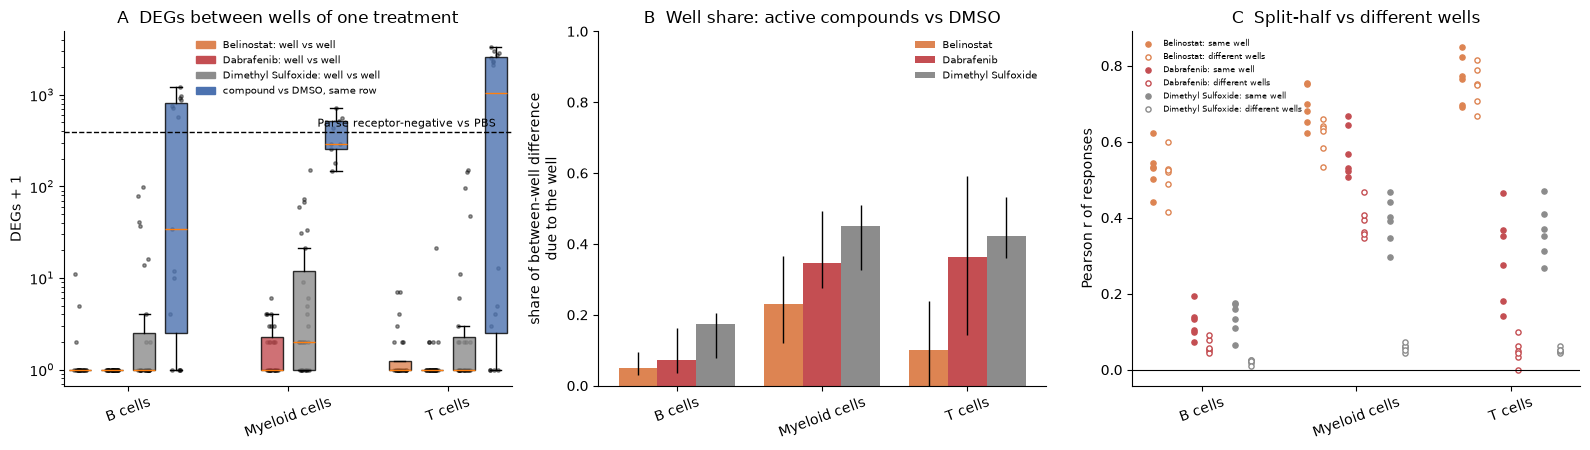

In [10]:
BLUE, ORANGE, GREY = "#4C72B0", "#DD8452", "#8C8C8C"
COL = {COND_ORDER[0]: ORANGE, COND_ORDER[1]: "#C44E52", DMSO_NAME: GREY}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

# A: DEGs (one box per treatment: well vs well of the same treatment; blue: compound vs DMSO)
x, xs, data, colors, ticks = 0, [], [], [], []
for ct in DEG_CELL_TYPES:
    start = x
    groups = [(DEG.kind == "same_treatment") & (DEG.cond == c) for c in COND_ORDER] + [DEG.kind == "vs_DMSO"]
    for g, c in zip(groups, [COL[c] for c in COND_ORDER] + [BLUE]):
        data.append(DEG[g & (DEG.ct == ct)]["n_deg"].to_numpy() + 1)
        colors.append(c); xs.append(x); x += 1
    ticks.append((start + x - 1) / 2); x += 1
bp = ax[0].boxplot([d if len(d) else [np.nan] for d in data], positions=xs, widths=0.7,
                   patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.8)
jit = np.random.default_rng(1)
for xi, d in zip(xs, data):
    ax[0].scatter(xi + jit.uniform(-0.2, 0.2, len(d)), d, s=6, color="k", alpha=0.4)
ax[0].axhline(PARSE_STRICT_INERT_DEG + 1, ls="--", color="k", lw=1)
ax[0].text(xs[-1], (PARSE_STRICT_INERT_DEG + 1) * 1.15, "Parse receptor-negative vs PBS",
           ha="right", fontsize=8)
ax[0].set_yscale("log"); ax[0].set_xticks(ticks); ax[0].set_xticklabels(DEG_CELL_TYPES, rotation=20)
ax[0].set_ylabel("DEGs + 1"); ax[0].set_title("A  DEGs between wells of one treatment")
handles = [plt.Rectangle((0, 0), 1, 1, color=COL[c]) for c in COND_ORDER] + [plt.Rectangle((0, 0), 1, 1, color=BLUE)]
ax[0].legend(handles, [f"{c}: well vs well" for c in COND_ORDER] + ["compound vs DMSO, same row"],
             fontsize=7, frameon=False)

# B: well share
w = 0.8 / len(COND_ORDER)
for k, cond in enumerate(COND_ORDER):
    s = T2_SUM[T2_SUM.cond == cond].set_index("ct").reindex(CELL_TYPES)
    x = np.arange(len(CELL_TYPES)) + (k - (len(COND_ORDER) - 1) / 2) * w
    ax[1].bar(x, s.share_median, w, color=COL[cond], label=cond)
    ax[1].vlines(x, s.share_min, s.share_max, color="k", lw=1)
ax[1].set_xticks(range(len(CELL_TYPES))); ax[1].set_xticklabels(CELL_TYPES, rotation=20)
ax[1].set_ylim(0, 1); ax[1].set_ylabel("share of between-well difference\ndue to the well")
ax[1].set_title("B  Well share: active compounds vs DMSO"); ax[1].legend(fontsize=7, frameon=False)

# C: ceiling
for k, cond in enumerate(COND_ORDER):
    s = T3[T3.cond == cond]
    for j, ct in enumerate(CELL_TYPES):
        q = s[s.ct == ct]
        x = j + (k - (len(COND_ORDER) - 1) / 2) * w
        ax[2].scatter(np.full(len(q), x - 0.05), q.same_well, color=COL[cond], s=14,
                      label=f"{cond}: same well" if j == 0 else None)
        ax[2].scatter(np.full(len(q), x + 0.05), q.different_wells, facecolor="white",
                      edgecolor=COL[cond], s=14, label=f"{cond}: different wells" if j == 0 else None)
ax[2].axhline(0, color="k", lw=0.8)
ax[2].set_xticks(range(len(CELL_TYPES))); ax[2].set_xticklabels(CELL_TYPES, rotation=20)
ax[2].set_ylabel("Pearson r of responses"); ax[2].set_title("C  Split-half vs different wells")
ax[2].legend(fontsize=6, frameon=False, ncol=1)

for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_OUT, dpi=200)
plt.show()

## 7. Numbers for the text

In [11]:
st = DEG[DEG.kind == "same_treatment"]
vs = DEG[DEG.kind == "vs_DMSO"]
comp = st[st.cond != DMSO_NAME]
print(f"DEGs between two wells of the same active compound: median {comp.n_deg.median():.0f} "
      f"(interior rows only {comp[~comp.edge].n_deg.median():.0f}); "
      f"DMSO well vs DMSO well: median {st[st.cond == DMSO_NAME].n_deg.median():.0f}; "
      f"compound vs DMSO in the same row: median {vs.n_deg.median():.0f}.")
for ct in CELL_TYPES:
    s = T2_SUM[T2_SUM.ct == ct].set_index("cond")
    print(f"{ct}: well share " + ", ".join(f"{c} {s.loc[c, 'share_median']:.2f}" for c in COND_ORDER if c in s.index)
          + "; well energy vs DMSO " + ", ".join(f"{c} {s.loc[c, 'energy_vs_DMSO']:.2f}" for c in COND_ORDER[:-1] if c in s.index))
for ct in CELL_TYPES:
    s = T3_SUM[T3_SUM.ct == ct].set_index("cond")
    print(f"{ct}: same well vs different wells " + ", ".join(
        f"{c} {s.loc[c, 'same_well']:.2f}/{s.loc[c, 'different_wells']:.2f}" for c in COND_ORDER if c in s.index))

DEGs between two wells of the same active compound: median 0 (interior rows only 0); DMSO well vs DMSO well: median 0; compound vs DMSO in the same row: median 288.
B cells: well share Belinostat 0.05, Dabrafenib 0.07, Dimethyl Sulfoxide 0.18; well energy vs DMSO Belinostat 0.38, Dabrafenib 0.50
Myeloid cells: well share Belinostat 0.23, Dabrafenib 0.35, Dimethyl Sulfoxide 0.45; well energy vs DMSO Belinostat 0.39, Dabrafenib 0.59
T cells: well share Belinostat 0.10, Dabrafenib 0.36, Dimethyl Sulfoxide 0.42; well energy vs DMSO Belinostat 0.21, Dabrafenib 0.75
B cells: same well vs different wells Belinostat 0.53/0.52, Dabrafenib 0.12/0.06, Dimethyl Sulfoxide 0.15/0.02
Myeloid cells: same well vs different wells Belinostat 0.69/0.63, Dabrafenib 0.55/0.38, Dimethyl Sulfoxide 0.40/0.06
T cells: same well vs different wells Belinostat 0.77/0.75, Dabrafenib 0.31/0.05, Dimethyl Sulfoxide 0.36/0.05


### How to read the results

- **Test 1.** Many DEGs between wells of an identical compound (compared with the compound-vs-DMSO
  count) means the fixed layout alone produces reproducible DEGs. Few DEGs means position alone does not
  explain the Parse floor; the per-well barcode or reagent, which in Parse are tied to the well, become
  the more likely source. Report either outcome.
- **Test 2.** Compound share close to DMSO: well noise does not depend on the treatment, so estimating
  it from control wells is justified. Clearly larger: well noise grows with the response (a limitation).
- **Test 3.** The gap between same-well and different-well correlations is how much the split-half
  ceiling overstates what can be predicted for a new well, now for an active compound.

## 8. Figure S4 for the paper

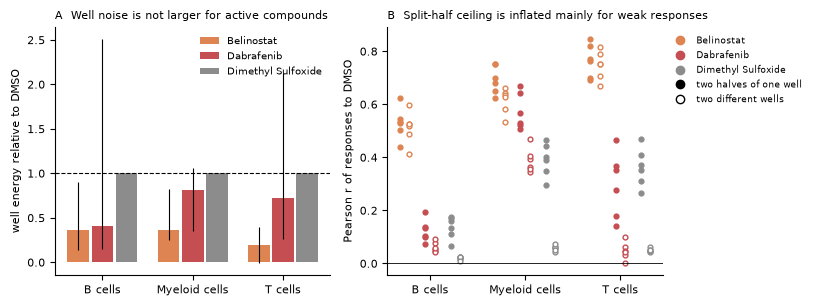

cond           Belinostat  Dabrafenib  Dimethyl Sulfoxide
ct                                                       
B cells              0.36        0.41                 1.0
Myeloid cells        0.37        0.81                 1.0
T cells              0.20        0.73                 1.0


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "savefig.dpi": 300, "savefig.bbox": "tight"})
COLS = dict(zip(COND_ORDER, ["#DD8452", "#C44E52", "#8C8C8C"]))

# well energy of each treatment relative to DMSO on the same plate and cell type
dm = T2[T2.cond == DMSO_NAME].set_index(["plate", "ct"])["well_energy"]
T2r = T2.copy()
T2r["rel"] = T2r.well_energy / [dm.get((p, c), np.nan) for p, c in zip(T2r.plate, T2r.ct)]
T2r.to_csv(os.path.join(CACHE_DIR, "test2_well_energy.csv"), index=False)
T3.to_csv(os.path.join(CACHE_DIR, "test3_split_half.csv"), index=False)

fig, ax = plt.subplots(1, 2, figsize=(8.2, 3.1))
w = 0.8 / len(COND_ORDER)
for k, cond in enumerate(COND_ORDER):
    s = T2r[T2r.cond == cond].groupby("ct").rel.agg(["median", "min", "max"]).reindex(CELL_TYPES)
    x = np.arange(len(CELL_TYPES)) + (k - (len(COND_ORDER) - 1) / 2) * w
    ax[0].bar(x, s["median"], w * 0.9, color=COLS[cond], label=cond)
    ax[0].vlines(x, s["min"], s["max"], color="k", lw=0.8)
ax[0].axhline(1, ls="--", color="k", lw=0.8)
ax[0].set_xticks(range(len(CELL_TYPES)))
ax[0].set_xticklabels(CELL_TYPES)
ax[0].set_ylabel("well energy relative to DMSO")
ax[0].legend(fontsize=7, frameon=False)
ax[0].set_title("A  Well noise is not larger for active compounds", loc="left", fontsize=8)

for k, cond in enumerate(COND_ORDER):
    for j, ct in enumerate(CELL_TYPES):
        q = T3[(T3.cond == cond) & (T3.ct == ct)]
        x = j + (k - (len(COND_ORDER) - 1) / 2) * w
        ax[1].scatter(np.full(len(q), x - 0.05), q.same_well, s=12, color=COLS[cond])
        ax[1].scatter(np.full(len(q), x + 0.05), q.different_wells, s=12, facecolor="white", edgecolor=COLS[cond])
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xticks(range(len(CELL_TYPES)))
ax[1].set_xticklabels(CELL_TYPES)
ax[1].set_ylabel("Pearson r of responses to DMSO")
handles = [Line2D([], [], marker="o", ls="", color=COLS[c], label=c) for c in COND_ORDER] + \
          [Line2D([], [], marker="o", ls="", color="k", label="two halves of one well"),
           Line2D([], [], marker="o", ls="", markerfacecolor="white", color="k", label="two different wells")]
ax[1].legend(handles=handles, fontsize=6.5, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax[1].set_title("B  Split-half ceiling is inflated mainly for weak responses", loc="left", fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "FigS4_op3_positive_controls.png"))
fig.savefig(os.path.join(FIG_DIR, "FigS4_op3_positive_controls.pdf"))
plt.show()
print(T2r.groupby(["ct", "cond"]).rel.median().unstack().round(2))